In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JN1AZ0CP5C,Stevens,Colville,WA,99114.0,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,7.0,153331706,POINT (-117.90454 48.54657),AVISTA CORP,5.306595e+10
1,JTMABABA7P,Yakima,Yakima,WA,98903.0,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,15.0,253586308,POINT (-120.71847 46.55029),PACIFICORP,5.307700e+10
2,1N4AZ1CP1J,King,Seattle,WA,98122.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151.0,37.0,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5UX43EU09S,Kitsap,Poulsbo,WA,98370.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,23.0,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303594e+10
4,3C3CFFGE5F,Thurston,Yelm,WA,98597.0,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87.0,2.0,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [7]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         279780 non-null  object 
 1   County                                             279756 non-null  object 
 2   City                                               279756 non-null  object 
 3   State                                              279780 non-null  object 
 4   Postal Code                                        279756 non-null  float64
 5   Model Year                                         279780 non-null  int64  
 6   Make                                               279780 non-null  object 
 7   Model                                              279780 non-null  object 
 8   Electric Vehicle Type                              279780 non-null  object

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

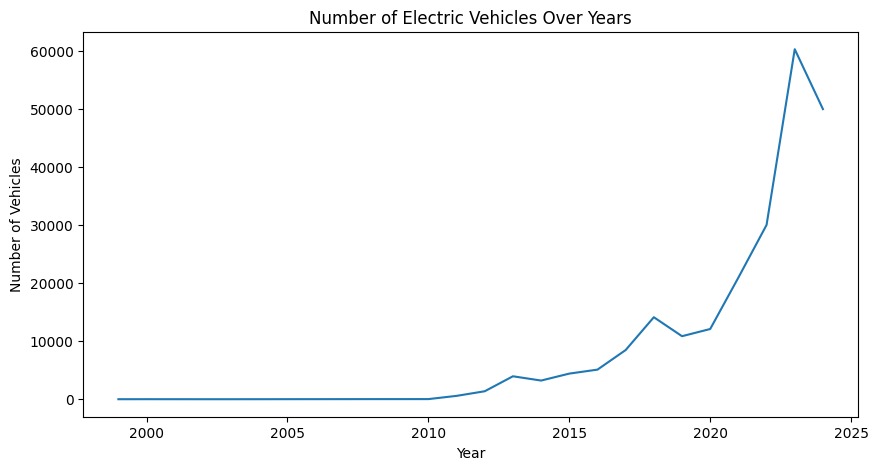

In [8]:
year_counts = df['Model Year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index < 2025]

plt.figure(figsize=(10,5))
year_counts.plot(kind='line')

plt.title("Number of Electric Vehicles Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")

plt.show()

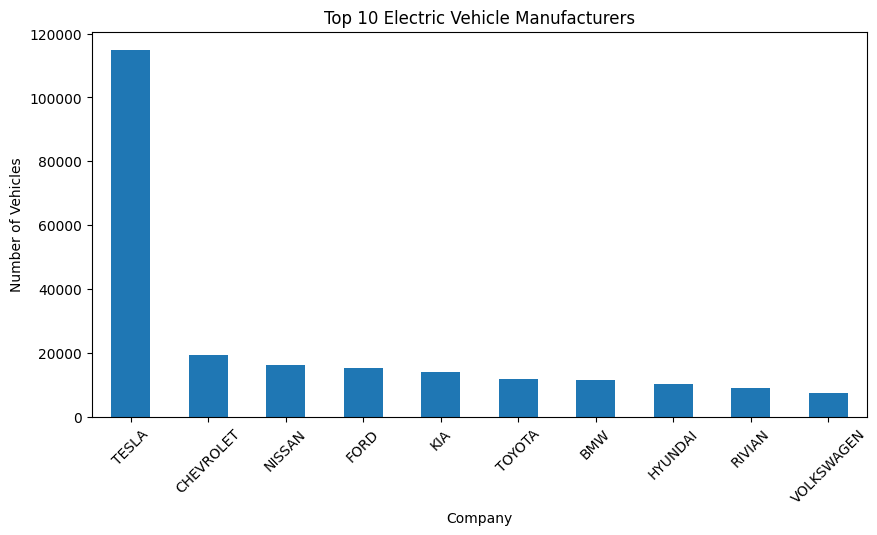

In [9]:
make_counts = df['Make'].value_counts().head(10)

plt.figure(figsize=(10,5))
make_counts.plot(kind='bar')

plt.title("Top 10 Electric Vehicle Manufacturers")
plt.xlabel("Company")
plt.ylabel("Number of Vehicles")

plt.xticks(rotation=45)
plt.show()

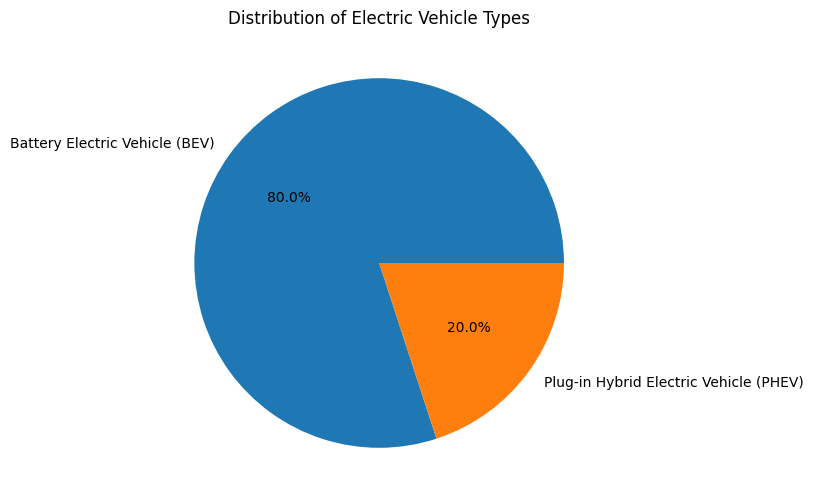

In [10]:
type_counts = df['Electric Vehicle Type'].value_counts()

plt.figure(figsize=(6,6))
type_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Distribution of Electric Vehicle Types")
plt.ylabel("")
plt.show()

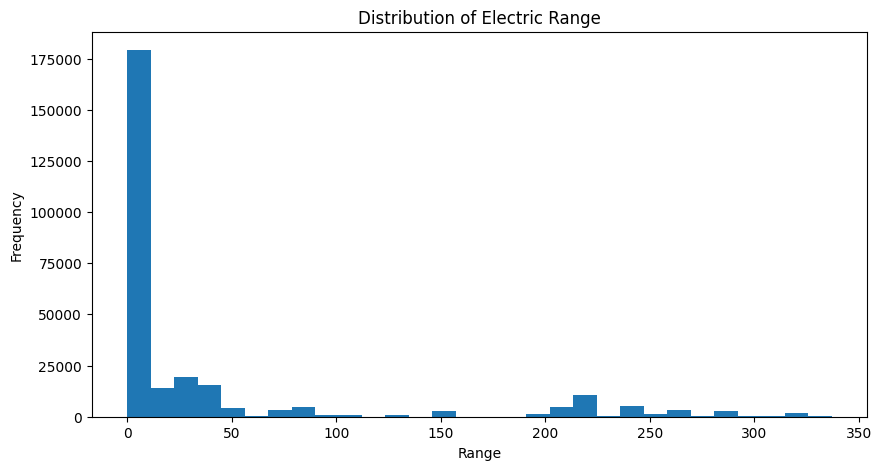

In [11]:
plt.figure(figsize=(10,5))

df['Electric Range'].plot(kind='hist', bins=30)

plt.title("Distribution of Electric Range")
plt.xlabel("Range")
plt.ylabel("Frequency")

plt.show()

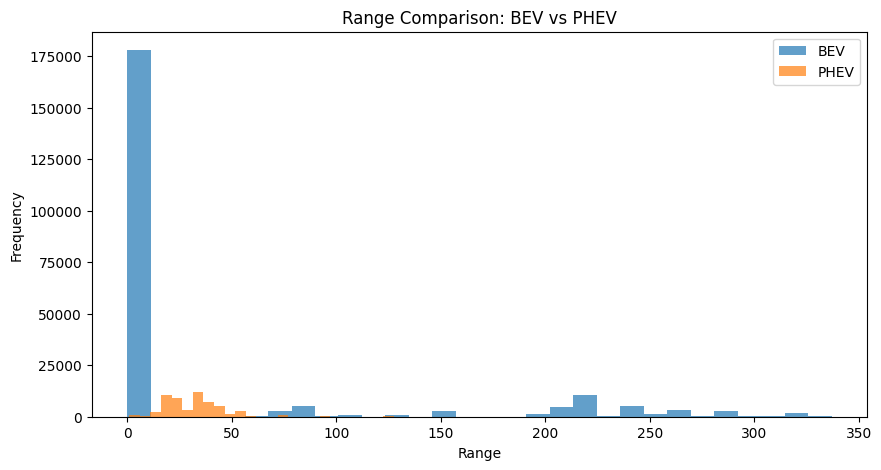

In [12]:
bev_range = df[df['Electric Vehicle Type'].str.contains('BEV')]['Electric Range']
phev_range = df[df['Electric Vehicle Type'].str.contains('PHEV')]['Electric Range']

plt.figure(figsize=(10,5))

plt.hist(bev_range, bins=30, alpha=0.7, label='BEV')
plt.hist(phev_range, bins=30, alpha=0.7, label='PHEV')

plt.legend()
plt.title("Range Comparison: BEV vs PHEV")
plt.xlabel("Range")
plt.ylabel("Frequency")

plt.show()

In [17]:
total = len(df)
tesla = len(df[df['Make'] == 'TESLA'])

percentage = (tesla / total) * 100

print("Tesla Market Share:", percentage)

Tesla Market Share: 41.04903853027378


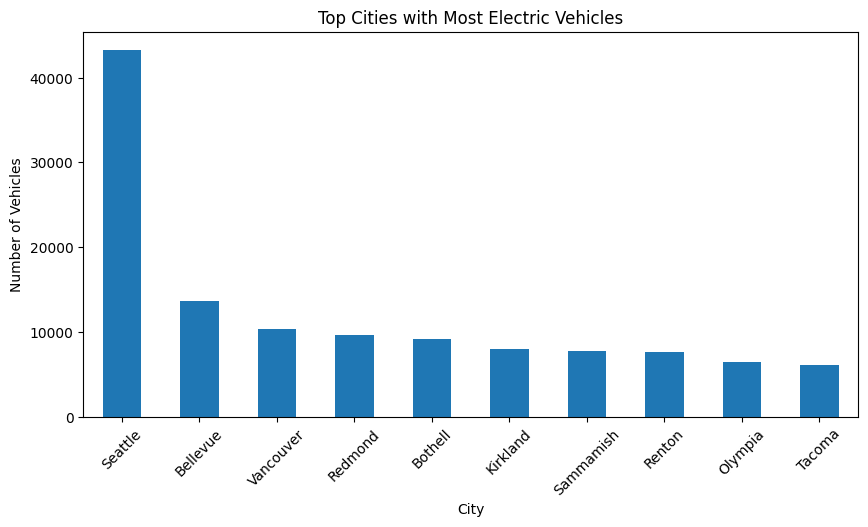

In [13]:
city_counts = df['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
city_counts.plot(kind='bar')

plt.title("Top Cities with Most Electric Vehicles")
plt.xlabel("City")
plt.ylabel("Number of Vehicles")

plt.xticks(rotation=45)
plt.show()

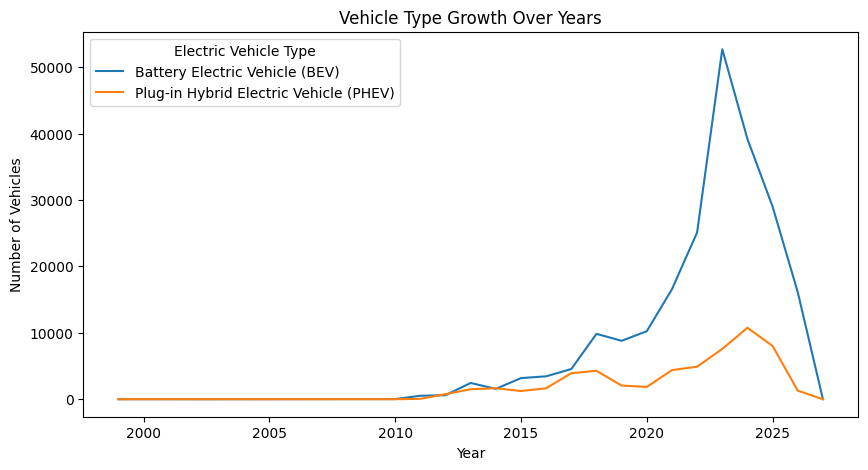

In [15]:
pivot = pd.crosstab(df['Model Year'], df['Electric Vehicle Type'])

pivot.plot(figsize=(10,5))

plt.title("Vehicle Type Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")

plt.show()

In [21]:
top_by_year = df.groupby(['Model Year', 'Make']).size().reset_index(name='Count')

idx = top_by_year.groupby('Model Year')['Count'].idxmax()
leaders = top_by_year.loc[idx]

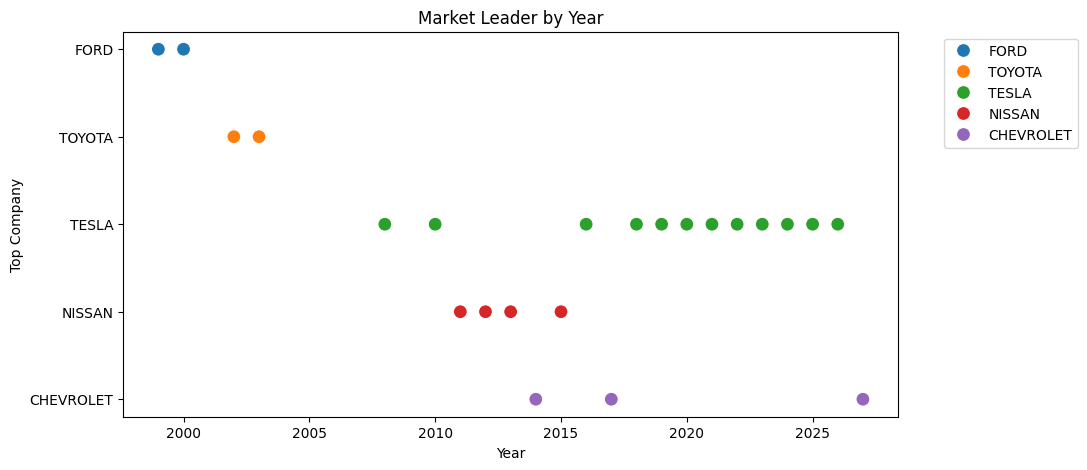

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.scatterplot(data=leaders, x='Model Year', y='Make', hue='Make', s=100)

plt.title("Market Leader by Year")
plt.xlabel("Year")
plt.ylabel("Top Company")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

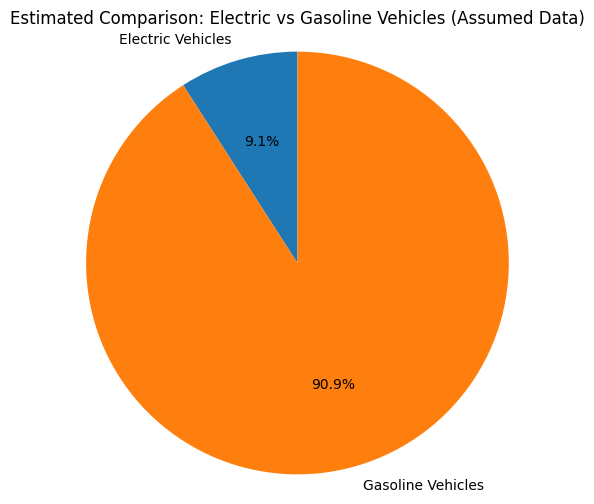

In [14]:
electric_count = len(df)
gas_count = electric_count * 10  # assumption

labels = ['Electric Vehicles', 'Gasoline Vehicles']
values = [electric_count, gas_count]

plt.figure(figsize=(6,6))

plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')

plt.title("Estimated Comparison: Electric vs Gasoline Vehicles (Assumed Data)")

plt.show()

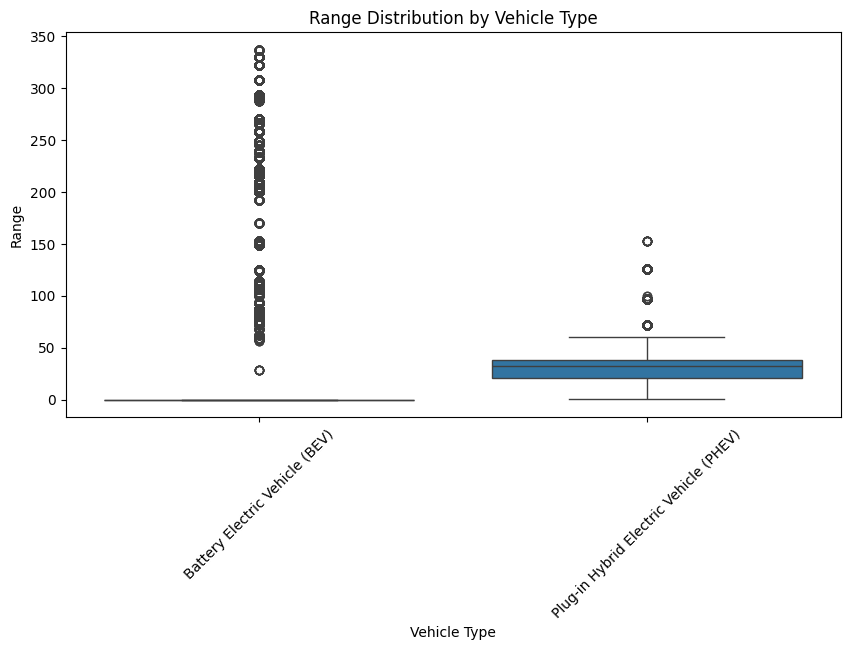

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df)

plt.xticks(rotation=45)

plt.title("Range Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Range")

plt.show()